In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "sales": [100, 200, 150, 300, 5000, 700, 3000, 1500, 400, 600]  # 5000 is an outlier
})

print(df.describe())

             sales
count    10.000000
mean   1195.000000
std    1603.546417
min     100.000000
25%     225.000000
50%     500.000000
75%    1300.000000
max    5000.000000


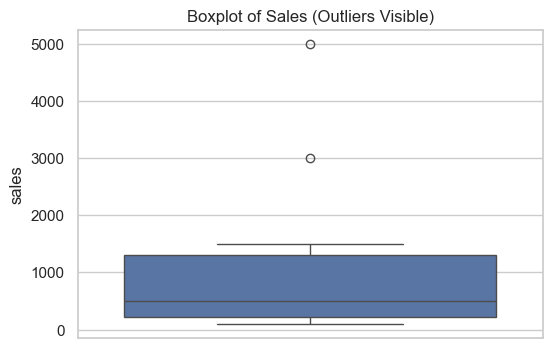

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style = "whitegrid")
plt.figure(figsize=(6,4))
sns.boxplot(
    y = df["sales"]
)
plt.title("Boxplot of Sales (Outliers Visible)")
plt.show()

In [3]:
# clipping outliners
from scipy.stats.mstats import winsorize

# clipping
df['sales_clipped'] = df['sales'].clip(upper=1000)

print(df)

   sales  sales_clipped
0    100            100
1    200            200
2    150            150
3    300            300
4   5000           1000
5    700            700
6   3000           1000
7   1500           1000
8    400            400
9    600            600


In [5]:
from scipy.stats.mstats import winsorize
df["sales_winsor"] = winsorize(df["sales"], limits = [0,0.2])
print(df)

   sales  sales_clipped  sales_winsor
0    100            100           100
1    200            200           200
2    150            150           150
3    300            300           300
4   5000           1000          1500
5    700            700           700
6   3000           1000          1500
7   1500           1000          1500
8    400            400           400
9    600            600           600


In [6]:
df["sales_removed"] = df["sales"].where(df["sales"] <= 1000, np.nan)
print(df)

   sales  sales_clipped  sales_winsor  sales_removed
0    100            100           100          100.0
1    200            200           200          200.0
2    150            150           150          150.0
3    300            300           300          300.0
4   5000           1000          1500            NaN
5    700            700           700          700.0
6   3000           1000          1500            NaN
7   1500           1000          1500            NaN
8    400            400           400          400.0
9    600            600           600          600.0


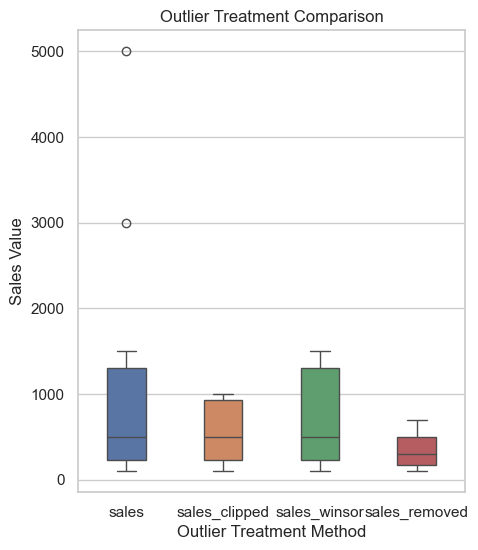

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set(style="whitegrid")

# Adjusting figsize: making it narrower (5) and slightly taller (6) 
# helps with the "squeezed" look
plt.figure(figsize=(5, 6))

# Use the 'width' parameter to squeeze the individual bars
sns.boxplot(
    data=df[["sales", "sales_clipped", "sales_winsor", "sales_removed"]],
    width=0.4  # Lowering this number (default is 0.8) makes the bars thinner
)

# Adding descriptive labels as seen in the updated version
plt.title("Outlier Treatment Comparison")
plt.ylabel("Sales Value")
plt.xlabel("Outlier Treatment Method")

plt.show()